Notebook per il **confronto** tra dati precedentemente estratti

Note: i dataset importati sono nella forma *anno,progetto*
Per aggiungere altri dati al confronto basta "importare" il dataset e aggiungere il suo nome dentro la lista *dataframe*

In [9]:
import pandas as pd

In [10]:
italia = "../dataset/esportazioni/it.csv"
spagna = "../dataset/esportazioni/sp.csv"
#francia = "../dataset/esportazioni/fr.csv"

it = pd.read_csv(italia)
sp = pd.read_csv(spagna)
#fr = pd.read_csv(francia)

dataframe = [it, sp]


In [11]:
it.head()

,anno,progetti
0,1998,1
1,1999,0
2,2000,0
3,2001,0
4,2002,4


In [12]:
sp.head()

,anno,progetti
0,1995,2
1,1996,1
2,1997,1
3,1998,0
4,1999,2


In [16]:
confronto = dataframe[0]
for df in dataframe[1:]:
    confronto = pd.merge(confronto, df, on="anno", how="outer")

confronto.rename(
    columns = {
        "anno":"anno",
        "progetti_x":"Italia",
        "progetti_y":"Spagna",
        #"progetto_z":"Francia"
        },
    inplace = True
)

confronto.fillna(0, inplace = True)

for colonna in confronto.columns:
    confronto[colonna] = confronto[colonna].astype(int)


confronto.head()


,anno,Italia,Spagna
0,1995,0,2
1,1996,0,1
2,1997,0,1
3,1998,1,0
4,1999,0,2


In [17]:
confronto

,anno,Italia,Spagna
0,1995,0,2
1,1996,0,1
2,1997,0,1
3,1998,1,0
4,1999,0,2
5,2000,0,2
6,2001,0,1
7,2002,4,1
8,2003,0,0
9,2004,2,1


[Text(1995, 0, '1995'),
 Text(1996, 0, '1996'),
 Text(1997, 0, '1997'),
 Text(1998, 0, '1998'),
 Text(1999, 0, '1999'),
 Text(2000, 0, '2000'),
 Text(2001, 0, '2001'),
 Text(2002, 0, '2002'),
 Text(2003, 0, '2003'),
 Text(2004, 0, '2004'),
 Text(2005, 0, '2005'),
 Text(2006, 0, '2006'),
 Text(2007, 0, '2007'),
 Text(2008, 0, '2008'),
 Text(2009, 0, '2009'),
 Text(2010, 0, '2010'),
 Text(2011, 0, '2011'),
 Text(2012, 0, '2012'),
 Text(2013, 0, '2013'),
 Text(2014, 0, '2014'),
 Text(2015, 0, '2015'),
 Text(2016, 0, '2016'),
 Text(2017, 0, '2017'),
 Text(2018, 0, '2018'),
 Text(2019, 0, '2019'),
 Text(2020, 0, '2020'),
 Text(2021, 0, '2021'),
 Text(2022, 0, '2022'),
 Text(2023, 0, '2023'),
 Text(2024, 0, '2024'),
 Text(2025, 0, '2025')]

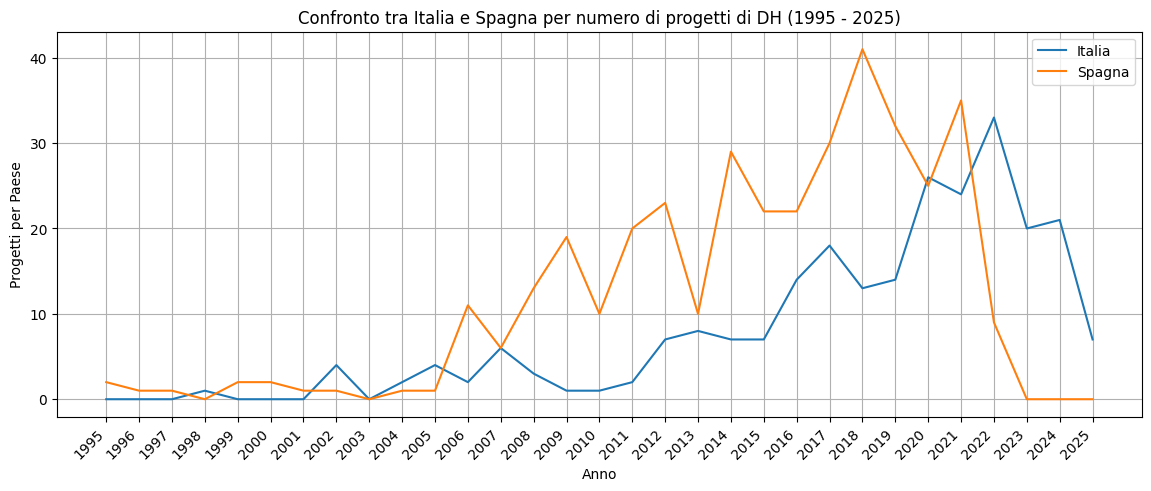

In [ ]:
paesi = confronto.columns[1:] #Recupera i nomi delle colonne, cioè dei Paesi

ax = confronto.plot(
    kind = "line",
    x = "anno",
    y = paesi,
    xlabel = "Anno",
    ylabel = "Progetti per Paese",
    grid = True,
    title = "Confronto tra Italia e Spagna per numero di progetti di DH (1995 - 2025)",
    figsize = (14, 6)
)

# Imposta tutte le etichette sull'asse x
ax.set_xticks(confronto["anno"])
ax.set_xticklabels(confronto["anno"], rotation=45, ha='right')  # Ruota e allinea le etichette